# 🧩 Preparação de Dados para Fine-Tuning

## 🎯 Objetivo
Este notebook prepara os datasets FinQA e FailureSensorIQ para fine-tuning em formato Instruct, mantendo o padrão de documentação do projeto.

## 🗂 Escopo
- Carregamento dos datasets brutos
- Transformação para `prompt` e `resposta` padronizados
- Normalização/limpeza e checagens de qualidade
- Geração de splits (train/val/test)
- Salvamento em JSONL prontos para FT

## 🧱 Padrão Instruct
Cada exemplo terá, no mínimo:
- `prompt`: texto de entrada para o modelo
- `resposta`: texto esperado (alvo)
- `meta`: metadados relevantes (dataset, split, tipo, etc.)



In [3]:
# Imports e configurações
import os
import json
import math
import random
import re
from collections import Counter
from typing import List, Dict

import numpy as np
import pandas as pd

# Reprodutibilidade
random.seed(42)
np.random.seed(42)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("🔧 Ambiente pronto.")


🔧 Ambiente pronto.


## 1) Carregamento dos Datasets
- FinQA: `FinQA/dataset/train.json` (e outros splits, se necessário)
- FailureSensorIQ: `FailureSensorIQ\FailureSensorIQ_unificado_instruct.jsonl`



In [4]:
# Funções de carregamento

def carregar_finqa(caminho_json: str) -> pd.DataFrame:
    try:
        with open(caminho_json, 'r', encoding='utf-8') as f:
            data = json.load(f)
        df = pd.DataFrame(data)
        print(f"FinQA carregado: {len(df)} registros de {caminho_json}")
        return df
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {caminho_json}")
        return pd.DataFrame()


def carregar_failure_sensoriq(caminho_jsonl: str) -> pd.DataFrame:
    try:
        data = []
        with open(caminho_jsonl, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    data.append(json.loads(line))
        df = pd.DataFrame(data)
        print(f"FailureSensorIQ carregado: {len(df)} registros de {caminho_jsonl}")
        return df
    except FileNotFoundError:
        print(f"Arquivo não encontrado: {caminho_jsonl}")
        return pd.DataFrame()


# Carregamento
finqa_df = carregar_finqa('FinQA/dataset/train.json')
fs_df = carregar_failure_sensoriq('FailureSensorIQ\FailureSensorIQ_unificado_instruct.jsonl')


FinQA carregado: 6251 registros de FinQA/dataset/train.json
FailureSensorIQ carregado: 8296 registros de FailureSensorIQ\FailureSensorIQ_unificado_instruct.jsonl


## 2) Transformação para Formato Instruct
- Unificar `prompt`/`resposta`
- Incluir `meta` com: `dataset`, `tipo`, `asset`, `fonte`, etc.



In [5]:
# Helpers

def limpar_texto(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip()
    # normalizações simples
    s = re.sub(r"\s+", " ", s)
    return s


def finqa_para_instruct(df: pd.DataFrame) -> List[Dict]:
    exemplos = []
    for i, row in df.iterrows():
        # Extrair campos de interesse
        pre = row.get('pre_text', [])
        post = row.get('post_text', [])
        qa = row.get('qa', {})
        table = row.get('table', [])
        question = limpar_texto(qa.get('question', '')) if isinstance(qa, dict) else ''
        answer = limpar_texto(qa.get('answer', '')) if isinstance(qa, dict) else ''
        program = qa.get('program', '') if isinstance(qa, dict) else ''

        # Converter tabela simples para texto (cabecalho + linhas)
        table_txt = ''
        if isinstance(table, list) and len(table) > 0:
            try:
                header = table[0]
                rows = table[1:]
                header_str = ' | '.join(str(x) for x in header)
                row_strs = [' | '.join(str(x) for x in r) for r in rows]
                table_txt = 'Tabela:\n' + header_str + '\n' + '\n'.join(row_strs)
            except Exception:
                table_txt = ''

        contexto = ''
        if isinstance(pre, list):
            contexto += ' '.join(str(x) for x in pre)
        if table_txt:
            contexto += '\n\n' + table_txt
        if isinstance(post, list) and len(post) > 0:
            contexto += '\n\n' + ' '.join(str(x) for x in post)
        contexto = limpar_texto(contexto)

        # FORMATO PLUG-AND-PLAY: ### Instruction: / ### Context: / ### Response:
        prompt = f"### Instruction:\n{question}\n\n### Context:\n{contexto}\n\n### Response:"
        resposta = answer

        meta = {
            'dataset': 'FinQA',
            'fonte': row.get('filename', ''),
            'program': program,
            'id': row.get('id', ''),
        }

        if prompt and resposta:
            exemplos.append({'prompt': prompt, 'resposta': resposta, 'meta': meta})
    return exemplos


def fs_para_instruct(df: pd.DataFrame) -> List[Dict]:
    exemplos = []
    for i, row in df.iterrows():
        # Extrair pergunta e contexto do prompt original
        prompt_original = limpar_texto(row.get('prompt', ''))
        resposta = limpar_texto(row.get('resposta', ''))
        tipo = row.get('question_type', '')
        asset = row.get('asset_name', '')
        
        # Separar pergunta do contexto (assumindo formato "Pergunta: ... Contexto: ...")
        if "Pergunta:" in prompt_original and "Contexto:" in prompt_original:
            parts = prompt_original.split("Contexto:")
            pergunta = parts[0].replace("Pergunta:", "").strip()
            contexto = parts[1].strip() if len(parts) > 1 else ""
        else:
            # Se não seguir o padrão, usar todo o prompt como pergunta
            pergunta = prompt_original
            contexto = ""
        
        # FORMATO PLUG-AND-PLAY: ### Instruction: / ### Context: / ### Response:
        if contexto:
            prompt = f"### Instruction:\n{pergunta}\n\n### Context:\n{contexto}\n\n### Response:"
        else:
            prompt = f"### Instruction:\n{pergunta}\n\n### Response:"
        
        meta = {
            'dataset': 'FailureSensorIQ',
            'tipo': tipo,
            'asset': asset
        }
        if prompt and resposta:
            exemplos.append({'prompt': prompt, 'resposta': resposta, 'meta': meta})
    return exemplos


finqa_instruct = finqa_para_instruct(finqa_df) if not finqa_df.empty else []
fs_instruct = fs_para_instruct(fs_df) if not fs_df.empty else []

print(f"FinQA convertidos: {len(finqa_instruct)}")
print(f"FailureSensorIQ convertidos: {len(fs_instruct)}")


FinQA convertidos: 6203
FailureSensorIQ convertidos: 8296


## 3) Limpeza, Normalização e Checagens
- Remover vazios, duplicados e entradas inconsistentes
- Normalizar espaços, quebras de linha e caracteres
- Checagens de qualidade dos exemplos gerados



In [6]:
# Limpeza

def limpar_lista_exemplos(exemplos: List[Dict]) -> List[Dict]:
    vistos = set()
    limpos = []
    for ex in exemplos:
        p = limpar_texto(ex.get('prompt', ''))
        r = limpar_texto(ex.get('resposta', ''))
        if not p or not r:
            continue
        chave = (p, r)
        if chave in vistos:
            continue
        vistos.add(chave)
        # normalização leve
        ex['prompt'] = p
        ex['resposta'] = r
        limpos.append(ex)
    return limpos


finqa_instruct = limpar_lista_exemplos(finqa_instruct)
fs_instruct = limpar_lista_exemplos(fs_instruct)

print(f"Após limpeza -> FinQA: {len(finqa_instruct)} | FailureSensorIQ: {len(fs_instruct)}")

# Checagens simples
assert all('prompt' in x and 'resposta' in x for x in finqa_instruct)
assert all('prompt' in x and 'resposta' in x for x in fs_instruct)



Após limpeza -> FinQA: 6156 | FailureSensorIQ: 8296


## 4) Splits Estratificados e Salvamento
- Split por dataset e tipo (quando aplicável)
- Arquivos de saída:
  - `data_ft/train.jsonl`
  - `data_ft/val.jsonl`
  - `data_ft/test.jsonl`



In [7]:
# Split e salvamento

def estratificar(exemplos: List[Dict], chave: str = None, ratios=(0.8, 0.1, 0.1)):
    # particiona mantendo proporções por chave se existir
    if not exemplos:
        return [], [], []
    by_key = {}
    if chave:
        for ex in exemplos:
            k = ex['meta'].get(chave, 'UNK') if 'meta' in ex else 'UNK'
            by_key.setdefault(k, []).append(ex)
    else:
        by_key['ALL'] = exemplos

    train, val, test = [], [], []
    for k, grupo in by_key.items():
        random.shuffle(grupo)
        n = len(grupo)
        n_train = int(n * ratios[0])
        n_val = int(n * ratios[1])
        train += grupo[:n_train]
        val += grupo[n_train:n_train+n_val]
        test += grupo[n_train+n_val:]
    return train, val, test


def salvar_jsonl(caminho: str, exemplos: List[Dict]):
    os.makedirs(os.path.dirname(caminho), exist_ok=True)
    with open(caminho, 'w', encoding='utf-8') as f:
        for ex in exemplos:
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")
    print(f"Salvo: {caminho} ({len(exemplos)} linhas)")


# Concatenar bases (mantendo metadados de origem)
base_unificada = []
base_unificada += finqa_instruct
base_unificada += fs_instruct
print(f"Total unificado: {len(base_unificada)}")

# Splits estratificados por dataset
train, val, test = estratificar(base_unificada, chave='dataset', ratios=(0.8, 0.1, 0.1))

salvar_jsonl('data_ft/train.jsonl', train)
salvar_jsonl('data_ft/val.jsonl', val)
salvar_jsonl('data_ft/test.jsonl', test)


Total unificado: 14452
Salvo: data_ft/train.jsonl (11560 linhas)
Salvo: data_ft/val.jsonl (1444 linhas)
Salvo: data_ft/test.jsonl (1448 linhas)


## 5) Estatísticas Finais e Instruções de Uso
- Resumo do número de exemplos por dataset e split
- Dicas para uso no fine-tuning (templates e parâmetros)



In [8]:
# Estatísticas e instruções

def contar_por_dataset(exemplos: List[Dict]):
    cont = Counter([ex.get('meta', {}).get('dataset', 'UNK') for ex in exemplos])
    return dict(cont)

print("Resumo por split:")
print({ 'train': contar_por_dataset(train), 'val': contar_por_dataset(val), 'test': contar_por_dataset(test) })

print("\nTemplate Plug-and-Play (conforme exigências):")
print("""\
### Instruction:
{pergunta}

### Context:
{contexto}

### Response:
{resposta}
""")

print("\nSugestão de parâmetros:")
print("- batch_size: 8-64 (ajustar à VRAM)")
print("- lr: 1e-5 a 2e-4")
print("- warmup_ratio: 0.03")
print("- max_seq_len: ajustar ao modelo (ex.: 4k)")


Resumo por split:
{'train': {'FinQA': 4924, 'FailureSensorIQ': 6636}, 'val': {'FinQA': 615, 'FailureSensorIQ': 829}, 'test': {'FinQA': 617, 'FailureSensorIQ': 831}}

Template Plug-and-Play (conforme exigências):
### Instruction:
{pergunta}

### Context:
{contexto}

### Response:
{resposta}


Sugestão de parâmetros:
- batch_size: 8-64 (ajustar à VRAM)
- lr: 1e-5 a 2e-4
- warmup_ratio: 0.03
- max_seq_len: ajustar ao modelo (ex.: 4k)


## 6) Visualizações dos Dados Finais (para Fine-Tuning)
- Distribuição por split e dataset
- Histogramas do tamanho de `prompt` e `resposta`
- Dispersão `len(prompt)` vs `len(resposta)` por dataset



split  dataset        
test   FailureSensorIQ     831
       FinQA               617
train  FailureSensorIQ    6636
       FinQA              4924
val    FailureSensorIQ     829
       FinQA               615
dtype: int64


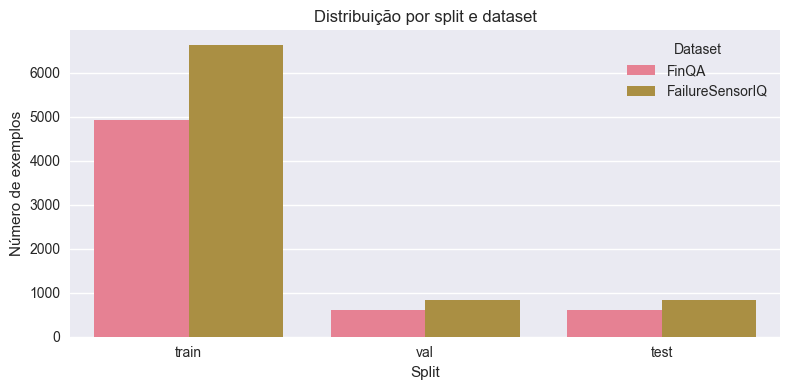

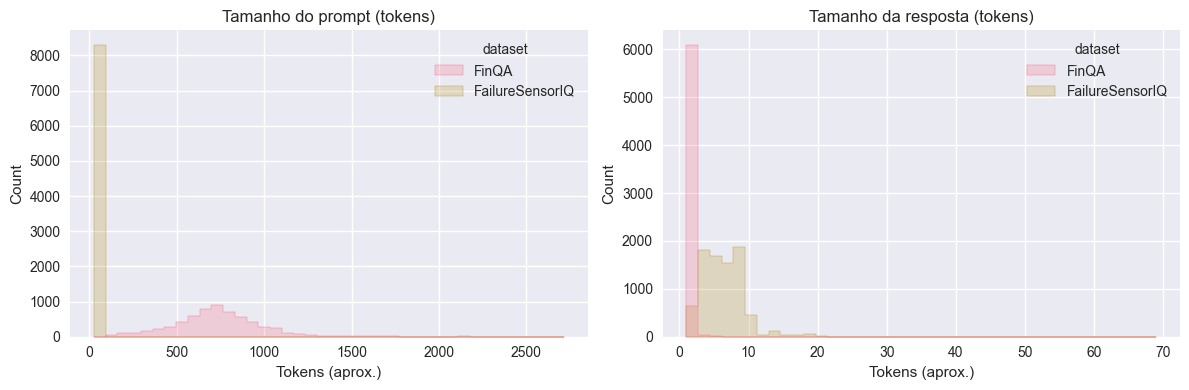

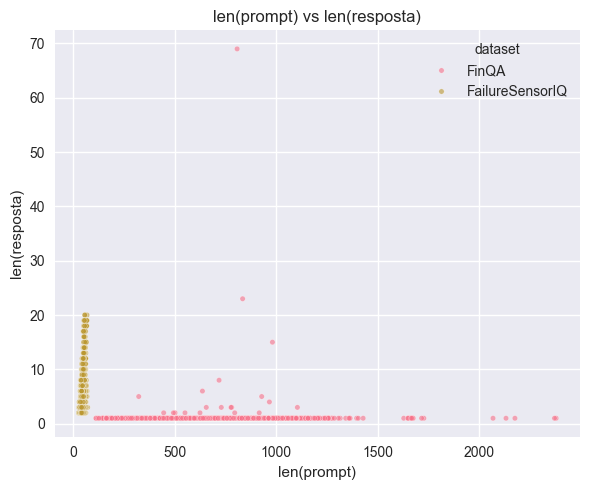

In [9]:
# Visualizações
import matplotlib.pyplot as plt
import seaborn as sns

# Construir DataFrames dos splits

def exemplos_para_df(exs, split):
    rows = []
    for ex in exs:
        ds = ex.get('meta', {}).get('dataset', 'UNK')
        p = ex.get('prompt', '')
        r = ex.get('resposta', '')
        rows.append({
            'dataset': ds,
            'split': split,
            'len_prompt': len(p.split()),
            'len_resposta': len(r.split())
        })
    return pd.DataFrame(rows)

df_train = exemplos_para_df(train, 'train')
df_val = exemplos_para_df(val, 'val')
df_test = exemplos_para_df(test, 'test')
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(df_all.groupby(['split','dataset']).size())

# 1) Distribuição por split e dataset
plt.figure(figsize=(8,4))
sns.countplot(data=df_all, x='split', hue='dataset')
plt.title('Distribuição por split e dataset')
plt.xlabel('Split')
plt.ylabel('Número de exemplos')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# 2) Histogramas de tamanho
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(data=df_all, x='len_prompt', hue='dataset', bins=40, ax=axes[0], element='step', stat='count')
axes[0].set_title('Tamanho do prompt (tokens)')
axes[0].set_xlabel('Tokens (aprox.)')

sns.histplot(data=df_all, x='len_resposta', hue='dataset', bins=40, ax=axes[1], element='step', stat='count')
axes[1].set_title('Tamanho da resposta (tokens)')
axes[1].set_xlabel('Tokens (aprox.)')

plt.tight_layout()
plt.show()

# 3) Dispersão len(prompt) vs len(resposta)
plt.figure(figsize=(6,5))
sns.scatterplot(data=df_all.sample(min(4000, len(df_all)), random_state=42), x='len_prompt', y='len_resposta', hue='dataset', s=15, alpha=0.6)
plt.title('len(prompt) vs len(resposta)')
plt.xlabel('len(prompt)')
plt.ylabel('len(resposta)')
plt.tight_layout()
plt.show()
